# Lab NLP 4h — Analyse de sentiment en français

**Version étudiant**

> Attention : le notebook est maintenant en **2 classes** (positif / negatif). Relancez *Restart & Run All* pour régénérer les sorties.

## Objectif pédagogique
Construire un mini-projet de **sentiment analysis en français** à partir d'avis de films Allocine ou tweets data base


Scénario final :
- 3 projets fictifs de computer vision (MediaPipe) sont présentés ;
- les étudiants écrivent des commentaires ;
- un modèle NLP prédit le sentiment (positif / négatif) ;
- on calcule un score final et un classement des projets.

Challenge (optionnel) : ajouter une classe **neutre**.

## Compétences visées
- charger un dataset NLP français (via HuggingFace) ;
- comprendre le **domain shift** et comment le réduire ;
- nettoyer et normaliser du texte ;
- tokenisation, lemmatisation et stopwords avec spaCy ;
- vectorisation **Bag of Words** et **TF-IDF** ;
- séparer les données en **train/test** ;
- entraîner et comparer **5 algorithmes de classification** ;
- inférence avec score de confiance ;
- exposer le résultat via une **app Flask** (avec ngrok sur Colab).


## Consignes (fil rouge)

Objectif : construire un mini-projet de **sentiment analysis en français** (positif / negatif) puis l'intégrer dans un mini-dashboard **Flask**.

Dans ce notebook, vous trouverez des blocs **what to do** et des **Challenges** (optionnels).

Minimum à rendre
- un pipeline entraîné + une évaluation (au moins TF-IDF + Logistic Regression) ;
- une fonction `predict_sentiment(...)` ;
- un classement des projets + lancement de l'app Flask.

Limites (à discuter)
- **domain shift** (films → projets) ;
- ironie / sarcasme ;
- négations et contexte ;
- vocabulaire (synonymes, OOV) ;
- probas parfois mal calibrées.


## Installation et prérequis

In [ ]:
import subprocess, sys

RUN_INSTALL = True

if RUN_INSTALL:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "pandas", "numpy", "matplotlib", "scikit-learn",
        "spacy", "datasets", "flask", "pyngrok",
    ])
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "fr_core_news_sm"])
else:
    print("Passez RUN_INSTALL = True si besoin.")


In [ ]:
from pathlib import Path
import re, unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 120)

from datasets import load_dataset
import spacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
LABEL_MAP    = {0: "negatif", 1: "positif"}
SCORE_MAP    = {"positif": 1, "negatif": -1}

print("Imports OK.")


Imports OK.


## 1. Introduction

**Problème :** classer un commentaire en positif / négatif.

> Bonus : ajouter une classe **neutre** .

### Contexte applicatif
Les étudiants réagissent à 3 projets ; le modèle lit chaque commentaire et produit un classement.

### Domain shift
> Un modèle entraîné sur des avis de films (Allocine) sera moins précis sur des commentaires de projets de computer vision (MediaPipe)


### Limites
L'ironie, le sarcasme et les négations restent difficiles pour les modèles classiques.

### what to do
- Relire le scenario et l objectif du lab.
- Identifier le domain shift (avis films -> projets computer vision MediaPipe).


## 2. Chargement du dataset Allocine (2 classes)

- labels originaux : `positif (1)` / `negatif (0)`
- on garde uniquement **2 classes** (binaire) pour le lab
- fallback synthétique si HuggingFace est indisponible

### what to do
- Charger le dataset Allocine (ou le fallback synthetique).
- Verifier le mapping labels (0=negatif, 1=positif).
- Afficher quelques exemples.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


def build_synthetic_dataset(n_per_class=800, random_state=42):
    rng = np.random.default_rng(random_state)
    pos_frag = ["super film", "vraiment excellent", "un chef-d'oeuvre",
                "magnifique realisation", "j'ai adore"]
    neg_frag = ["tres decevant", "une vraie deception", "mauvais film",
                "scenario nul", "acteurs mediocres"]
    contexts = ["Pour ce film,", "Cette comedie", "Le long-metrage", ""]
    rows = []
    for label, fragments in [(0, neg_frag), (1, pos_frag)]:
        for _ in range(n_per_class):
            ctx  = rng.choice(contexts)
            frag = rng.choice(fragments)
            rows.append({"review": f"{ctx} {frag}".strip(), "label": label})
    return pd.DataFrame(rows).sample(frac=1, random_state=random_state).reset_index(drop=True)


LABEL_MAP      = {0: "negatif", 1: "positif"}
RANDOM_STATE   = 42
df_train_full  = None
df_test_full   = pd.DataFrame()
dataset_source = None

try:
    print("Telechargement Allocine depuis HuggingFace...")
    raw = load_dataset("allocine", trust_remote_code=True)

    def hf_to_df(split):
        df = pd.DataFrame({"review": split["review"], "label": split["label"]})
        df["sentiment"] = df["label"].map(LABEL_MAP)
        return df[["review", "label", "sentiment"]]

    df_train_full = hf_to_df(raw["train"])
    df_test_full  = hf_to_df(raw["test"])
    dataset_source = "allocine_hf"
    print(f"Dataset Allocine charge — train={len(df_train_full)}, test={len(df_test_full)}")

except Exception as e:
    print(f"Fallback synthetique ({e})")
    df_synth = build_synthetic_dataset(n_per_class=800, random_state=RANDOM_STATE)
    df_synth["sentiment"] = df_synth["label"].map(LABEL_MAP)
    df_train_full, df_test_full = train_test_split(
        df_synth, test_size=0.15, stratify=df_synth["label"], random_state=RANDOM_STATE
    )
    dataset_source = "synthetique"

print(f"Source : {dataset_source}")
display(df_train_full.head())


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'allocine' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'allocine' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Telechargement Allocine depuis HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

allocine/train-00000-of-00001.parquet:   0%|          | 0.00/60.0M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/160000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20000 [00:00<?, ? examples/s]

Dataset Allocine charge — train=160000, test=20000
Source : allocine_hf


,review,label,sentiment
0,"Si vous cherchez du cinéma abrutissant à tous les étages,n'ayant aucune peur du cliché en castagnettes et moralement...",0,negatif
1,"Trash, re-trash et re-re-trash...! Une horreur sans nom. Imaginez-vous les 20 premières minutes de Orange Mécanique ...",0,negatif
2,"Et si, dans les 5 premières minutes du film, la pathétique maquette de train fendant la neige en gros plan laissait ...",0,negatif
3,"Mon dieu ! Quelle métaphore filée ! Je suis abasourdi ! Mais réellement, ici on a une métaphore filée de l'acceptati...",0,negatif
4,"Premier film de la saga Kozure Okami, ""Le Sabre de la vengeance"" est un très bon film qui mêle drame et action, et q...",1,positif


## 3. Exploration du dataset
### what to do
- Explorer la distribution des labels.
- Analyser la longueur des textes (nb mots) et les outliers.


,split,sentiment,nb_avis
0,test,negatif,10408
1,test,positif,9592
2,train,negatif,79413
3,train,positif,80587


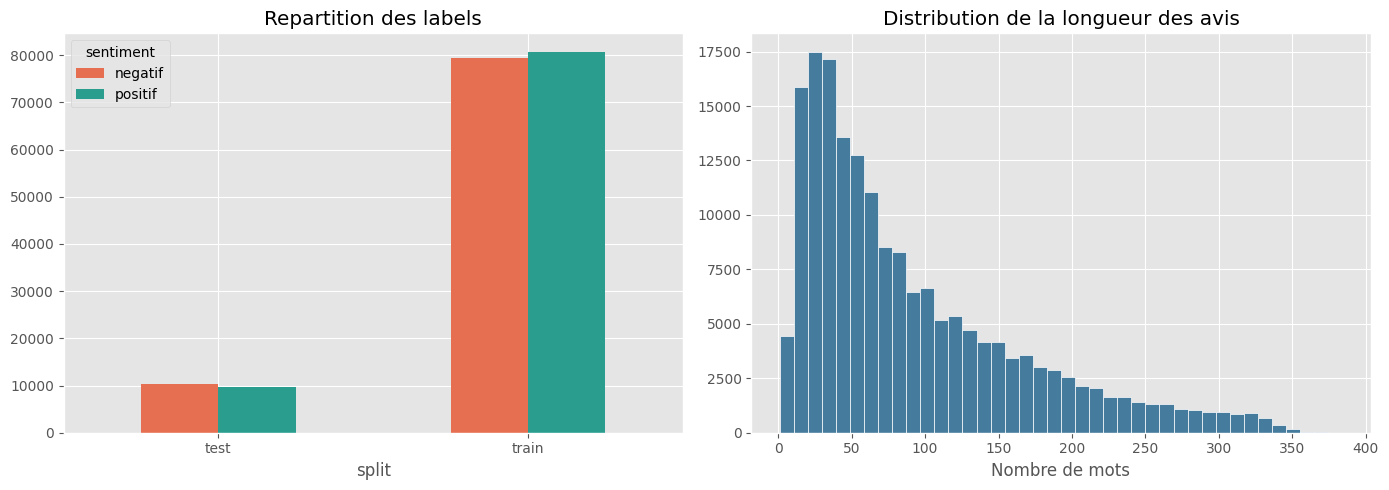

In [ ]:
df_eda = pd.concat([
    df_train_full.assign(split="train"),
    df_test_full.assign(split="test"),
], ignore_index=True)

label_dist = (
    df_eda.groupby(["split", "sentiment"])
    .size().reset_index(name="nb_avis")
)
display(label_dist)

df_eda["nb_mots"] = df_eda["review"].fillna("").str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot = label_dist.pivot(index="split", columns="sentiment", values="nb_avis").fillna(0)
pivot = pivot.reindex(columns=["negatif", "positif"], fill_value=0)
pivot.plot(kind="bar", ax=axes[0], color=["#e76f51", "#2a9d8f"])
axes[0].set_title("Repartition des labels")
axes[0].tick_params(axis="x", rotation=0)

axes[1].hist(df_eda["nb_mots"], bins=40, color="#457b9d", edgecolor="white")
axes[1].set_title("Distribution de la longueur des avis")
axes[1].set_xlabel("Nombre de mots")

plt.tight_layout(); plt.show()


## 4. Nettoyage et prétraitement

### Nettoyage
Suppression URLs, mentions, hashtags, chiffres, ponctuation excessive.

### spaCy — tokenisation, lemmatisation, stopwords

### what to do
- Implementer `basic_clean_text` puis tester sur des exemples.
- Option: ajouter une normalisation + regex plus robuste.


In [ ]:
def basic_clean_text(text):
    # what to do (minimum)
    # - gérer NaN / None
    # - unicode normalize (NFKC)
    # - minuscules
    # - supprimer URLs / mentions / hashtags
    # - supprimer chiffres
    # - nettoyer ponctuation / espaces

    text = "" if pd.isna(text) else str(text)

    # what to do: normaliser unicode
    # text = unicodedata.normalize("NFKC", text)

    # what to do: minuscules
    # text = text.lower()

    # what to do: regex (urls, mentions, hashtags, chiffres, ponctuation)
    # text = re.sub(...)

    # what to do: espaces multiples
    # text = re.sub(r"\s+", " ", text).strip()

    return text

# Petit test
sample = "J'ADORE ce ProJet !!! 10/10 @user Mais il existe sur www.github.com"
print("Original :", sample)
print("Nettoye  :", basic_clean_text(sample))


Original : J'ADORE ce ProJet !!! 10/10 @user Mais il existe sur www.github.com
Nettoye  : J'ADORE ce ProJet !!! 10/10 @user Mais il existe sur www.github.com


In [ ]:
try:
    nlp = spacy.load("fr_core_news_sm")
except OSError:
    raise OSError("Modele spaCy manquant : python -m spacy download fr_core_news_sm")

phrase = "J'ADORE ce ProJet !!! 10/10 @user Mais il éXISte sur www.github.com"
doc = nlp(phrase)

token_table = pd.DataFrame([
    {"token": t.text, "lemme": t.lemma_, "stopword": t.is_stop, "ponctuation": t.is_punct}
    for t in doc
])
display(token_table)


,token,lemme,stopword,ponctuation
0,J',je,True,False
1,ADORE,adorer,False,False
2,ce,ce,True,False
3,ProJet,projet,False,False
4,!,!,False,True
5,!,!,False,True
6,!,!,False,True
7,10/10,10/10,False,False
8,@user,@user,False,False
9,Mais,mais,True,False


## 5. Séparation train / test (stratifiée)
### what to do
- Faire un split train/test stratifie et verifier les proportions.


In [ ]:
sample_size = min(12_000, len(df_train_full))
df_lab, _ = train_test_split(
    df_train_full,
    train_size=sample_size,
    stratify=df_train_full["label"],
    random_state=RANDOM_STATE,
)
df_lab = df_lab.copy()
df_lab["review_clean"] = df_lab["review"].apply(basic_clean_text)

X_train, X_test, y_train, y_test = train_test_split(
    df_lab["review_clean"],
    df_lab["label"],
    test_size=0.2,
    stratify=df_lab["label"],
    random_state=RANDOM_STATE,
)

print(f"Train : {len(X_train)}  |  Test : {len(X_test)}")
print("\nDistribution y_train :")
print(pd.Series(y_train).map(LABEL_MAP).value_counts())


Train : 9600  |  Test : 2400

Distribution y_train :
label
positif    4835
negatif    4765
Name: count, dtype: int64


## 6. Bag of Words (démonstration)
### what to do
- Tester `CountVectorizer` (ngram_range, max_features, min_df).
- Observer l impact sur les performances.


In [ ]:
toy_corpus = ["excellent film utile", "film banal et mal joue", "excellent et innovant"]

toy_bow    = CountVectorizer()
bow_matrix = toy_bow.fit_transform(toy_corpus)

bow_demo = pd.DataFrame(
    bow_matrix.toarray(),
    columns=toy_bow.get_feature_names_out(),
    index=[f"texte_{i}" for i in range(len(toy_corpus))],
)
display(bow_demo)


,banal,et,excellent,film,innovant,joue,mal,utile
texte_0,0,0,1,1,0,0,0,1
texte_1,1,1,0,1,0,1,1,0
texte_2,0,1,1,0,1,0,0,0


## 7. TF-IDF (démonstration)
### what to do
- Tester `TfidfVectorizer` (ngram_range, max_features, min_df).
- Comparer BoW vs TF-IDF.


In [ ]:
toy_tfidf    = TfidfVectorizer()
tfidf_matrix = toy_tfidf.fit_transform(toy_corpus)

tfidf_demo = pd.DataFrame(
    np.round(tfidf_matrix.toarray(), 3),
    columns=toy_tfidf.get_feature_names_out(),
    index=[f"texte_{i}" for i in range(len(toy_corpus))],
)
display(tfidf_demo)


,banal,et,excellent,film,innovant,joue,mal,utile
texte_0,0.00,0.000,0.518,0.518,0.000,0.00,0.00,0.681
texte_1,0.49,0.373,0.000,0.373,0.000,0.49,0.49,0.000
texte_2,0.00,0.518,0.518,0.000,0.681,0.00,0.00,0.000


## 8. Comparaison de 5 algorithmes

| # | Vectorisation | Classifieur |
|---|---|---|
| 1 | BoW | MultinomialNB |
| 2 | BoW | ComplementNB |
| 3 | TF-IDF (1-2 grammes) | LogisticRegression |
| 4 | TF-IDF (1-2 grammes) | LinearSVC |
| 5 | TF-IDF | GradientBoostingClassifier |

Métrique principale : **F1 pondéré** (OK pour 2 classes, robuste en cas de léger déséquilibre).

### what to do
- Implementer `evaluate_pipeline(...)`.
- Ajouter au moins 3 pipelines et comparer accuracy / f1_weighted.


In [ ]:
def evaluate_pipeline(name, pipeline, X_tr, X_te, y_tr, y_te):
    # Entraine + evalue un pipeline.
    #
    # what to do
    # - entrainer le pipeline
    # - predire sur X_te
    # - calculer accuracy et f1_weighted
    # - retourner un dict: {pipeline, y_pred, metrics}
    #
    # Retour attendu (exemple):
    # {
    #   "pipeline": pipeline,
    #   "y_pred": y_pred,
    #   "metrics": {"modele": name, "accuracy": ..., "f1_weighted": ...},
    # }

    # Votre code ici
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    accuracy = accuracy_score(y_te, y_pred)
    f1_weighted = f1_score(y_te, y_pred, average="weighted")

    return {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "metrics": {"modele": name, "accuracy": accuracy, "f1_weighted": f1_weighted},
    }


pipelines = {
    # what to do: ajouter au moins 3 autres variantes et comparer
    # Exemples attendus:
    # - BoW + MultinomialNB
    # - BoW + ComplementNB
    # - TF-IDF + LinearSVC
    # - TF-IDF + GradientBoosting

    "1. BoW + MultinomialNB": Pipeline([
        ("vect", CountVectorizer(max_features=20_000, min_df=2, ngram_range=(1, 2))),
        ("clf",  MultinomialNB()),
    ]),
    "2. BoW + ComplementNB": Pipeline([
        ("vect", CountVectorizer(max_features=20_000, min_df=2, ngram_range=(1, 2))),
        ("clf",  ComplementNB()),
    ]),
    "3. TF-IDF + Logistic Regression": Pipeline([
        ("vect", TfidfVectorizer(max_features=20_000, min_df=2, ngram_range=(1, 2))),
        ("clf",  LogisticRegression(max_iter=1000, C=1.0)),
    ]),
    "4. TF-IDF + LinearSVC": Pipeline([
        ("vect", TfidfVectorizer(max_features=20_000, min_df=2, ngram_range=(1, 2))),
        ("clf",  LinearSVC(random_state=RANDOM_STATE, dual=True)),
    ]),
    "5. TF-IDF + GradientBoosting": Pipeline([
        ("vect", TfidfVectorizer(max_features=20_000, min_df=2, ngram_range=(1, 2))),
        ("clf",  GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),

}

results = {}
for name, pipe in pipelines.items():
    print(f"Entrainement : {name} ...")
    results[name] = evaluate_pipeline(name, pipe, X_train, X_test, y_train, y_test)
    m = results[name]["metrics"]
    print(f"  accuracy={m['accuracy']:.3f}  f1_weighted={m['f1_weighted']:.3f}")

print("Tous les modeles entraines.")

Entrainement : 1. BoW + MultinomialNB ...
  accuracy=0.902  f1_weighted=0.902
Entrainement : 2. BoW + ComplementNB ...
  accuracy=0.902  f1_weighted=0.902
Entrainement : 3. TF-IDF + Logistic Regression ...
  accuracy=0.896  f1_weighted=0.896
Entrainement : 4. TF-IDF + LinearSVC ...
  accuracy=0.905  f1_weighted=0.905
Entrainement : 5. TF-IDF + GradientBoosting ...
  accuracy=0.821  f1_weighted=0.821
Tous les modeles entraines.


### Tableau comparatif

In [ ]:
comparison_df = (
    pd.DataFrame([r["metrics"] for r in results.values()])
    .sort_values("f1_weighted", ascending=False)
    .reset_index(drop=True)
)
display(comparison_df.style.format({"accuracy": "{:.3f}", "f1_weighted": "{:.3f}"}))

,modele,accuracy,f1_weighted
0,4. TF-IDF + LinearSVC,0.905,0.905
1,1. BoW + MultinomialNB,0.902,0.902
2,2. BoW + ComplementNB,0.902,0.902
3,3. TF-IDF + Logistic Regression,0.896,0.896
4,5. TF-IDF + GradientBoosting,0.821,0.821


### Matrices de confusion

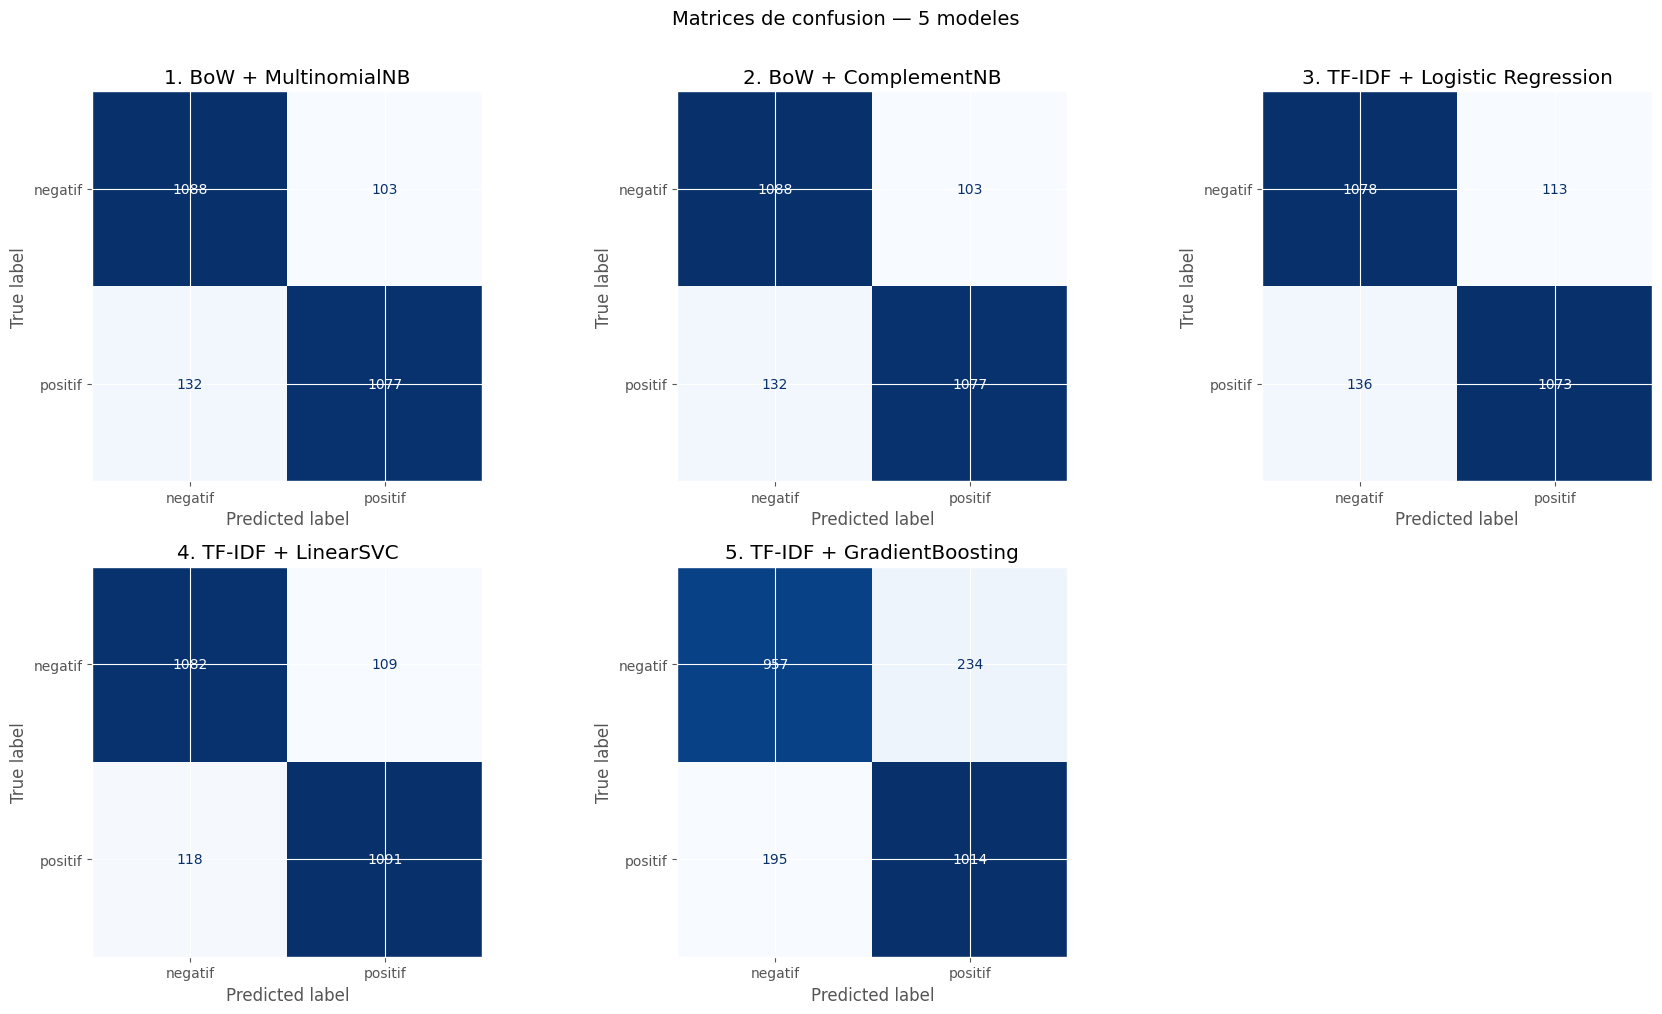

In [ ]:
class_labels = ["negatif", "positif"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=class_labels,
        cmap="Blues", colorbar=False, ax=axes[i],
    )
    axes[i].set_title(name)

axes[-1].set_visible(False)
plt.suptitle("Matrices de confusion — 5 modeles", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 9. Rapport du meilleur modèle
### what to do
- Choisir le meilleur modele et expliquer pourquoi.
- Lire et interpreter le `classification_report`.


In [ ]:
best_name   = comparison_df.iloc[0]["modele"]
best_result = results[best_name]

print(f"Meilleur modele : {best_name}\n")
print(classification_report(
    y_test, best_result["y_pred"],
    target_names=["negatif", "positif"],
))

final_model = best_result["pipeline"]


Meilleur modele : 4. TF-IDF + LinearSVC

              precision    recall  f1-score   support

     negatif       0.90      0.91      0.91      1191
     positif       0.91      0.90      0.91      1209

    accuracy                           0.91      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.91      0.91      0.91      2400



## 10. Interprétabilité — mots les plus discriminants (Logistic Regression)
### what to do
- Identifier les mots les plus discriminants (positif/negatif).
- Verifier si ca fait sens avec le domain.


In [ ]:
lr_pipeline   = results["3. TF-IDF + Logistic Regression"]["pipeline"]
vectorizer_lr = lr_pipeline.named_steps["vect"]
classifier_lr = lr_pipeline.named_steps["clf"]
feature_names = vectorizer_lr.get_feature_names_out()

coefs = classifier_lr.coef_[0]

top_pos = pd.DataFrame({
    "mot":   feature_names[np.argsort(coefs)[-10:]][::-1],
    "poids": np.sort(coefs)[-10:][::-1],
})
top_neg = pd.DataFrame({
    "mot":   feature_names[np.argsort(coefs)[:10]],
    "poids": np.sort(coefs)[:10],
})

print("\n--- Top 10 mots -> 'positif' ---")
display(top_pos)
print("\n--- Top 10 mots -> 'negatif' ---")
display(top_neg)



--- Top 10 mots -> 'positif' ---


,mot,poids
0,excellent,4.458647
1,et,3.783000
2,magnifique,3.765819
3,très bon,3.176377
4,très,3.135751
5,voir,3.003977
6,bon,2.814669
7,film,2.714886
8,superbe,2.710241
9,bien,2.447911



--- Top 10 mots -> 'negatif' ---


,mot,poids
0,mauvais,-5.033890
1,rien,-4.123499
2,pas,-4.064787
3,ennuyeux,-3.784804
4,navet,-3.738562
5,nul,-3.673491
6,intérêt,-3.554566
7,trop,-3.468003
8,ennui,-3.146560
9,mal,-3.090098


## 11. Projets fictifs et commentaires d'exemple
### what to do
- Adapter/completez les 3 projets (computer vision avec MediaPipe).
- Ajouter des commentaires etudiants a evaluer.


In [ ]:
projects_df = pd.DataFrame([
    {
        "projet": "Projet A – Coach fitness (MediaPipe Pose)",
        "description": "Compter des repetitions (squats/pompes) et corriger la posture en temps reel avec MediaPipe Pose.",
    },
    {
        "projet": "Projet B – Controle gestuel (MediaPipe Hands)",
        "description": "Controler un lecteur media / des slides avec des gestes de la main (play/pause/volume) via MediaPipe Hands.",
    },
    {
        "projet": "Projet C – Filtre AR visage (MediaPipe Face Mesh)",
        "description": "Appliquer un filtre AR (masque/lunettes) et segmenter l'arriere-plan via Face Mesh + Selfie Segmentation.",
    },
])
display(projects_df)

comments_df = pd.DataFrame([
    {
        "auteur": "Ex 1",
        "projet": "Projet A – Coach fitness (MediaPipe Pose)",
        "commentaire": "Super idee, un coach fitness avec MediaPipe Pose serait tres utile pour s'entrainer.",
        "source": "exemple",
    },
    {
        "auteur": "Ex 2",
        "projet": "Projet A – Coach fitness (MediaPipe Pose)",
        "commentaire": "Bof, ca existe deja et la detection de posture risque d'etre imprecise.",
        "source": "exemple",
    },
    {
        "auteur": "Ex 3",
        "projet": "Projet B – Controle gestuel (MediaPipe Hands)",
        "commentaire": "Tres pratique : controler des slides avec la main, sans toucher le clavier.",
        "source": "exemple",
    },
    {
        "auteur": "Ex 4",
        "projet": "Projet B – Controle gestuel (MediaPipe Hands)",
        "commentaire": "Les gestes vont etre fatigants et ca marchera mal en faible lumiere.",
        "source": "exemple",
    },
    {
        "auteur": "Ex 5",
        "projet": "Projet C – Filtre AR visage (MediaPipe Face Mesh)",
        "commentaire": "Excellent, le filtre AR visage peut etre un vrai plus pour le e-commerce.",
        "source": "exemple",
    },
    {
        "auteur": "Ex 6",
        "projet": "Projet C – Filtre AR visage (MediaPipe Face Mesh)",
        "commentaire": "Trop gadget et ca pose des problemes de confidentialite.",
        "source": "exemple",
    },
])
display(comments_df)


,projet,description
0,Projet A – Coach fitness (MediaPipe Pose),Compter des repetitions (squats/pompes) et corriger la posture en temps reel avec MediaPipe Pose.
1,Projet B – Controle gestuel (MediaPipe Hands),Controler un lecteur media / des slides avec des gestes de la main (play/pause/volume) via MediaPipe Hands.
2,Projet C – Filtre AR visage (MediaPipe Face Mesh),Appliquer un filtre AR (masque/lunettes) et segmenter l'arriere-plan via Face Mesh + Selfie Segmentation.


,auteur,projet,commentaire,source
0,Ex 1,Projet A – Coach fitness (MediaPipe Pose),"Super idee, un coach fitness avec MediaPipe Pose serait tres utile pour s'entrainer.",exemple
1,Ex 2,Projet A – Coach fitness (MediaPipe Pose),"Bof, ca existe deja et la detection de posture risque d'etre imprecise.",exemple
2,Ex 3,Projet B – Controle gestuel (MediaPipe Hands),"Tres pratique : controler des slides avec la main, sans toucher le clavier.",exemple
3,Ex 4,Projet B – Controle gestuel (MediaPipe Hands),Les gestes vont etre fatigants et ca marchera mal en faible lumiere.,exemple
4,Ex 5,Projet C – Filtre AR visage (MediaPipe Face Mesh),"Excellent, le filtre AR visage peut etre un vrai plus pour le e-commerce.",exemple
5,Ex 6,Projet C – Filtre AR visage (MediaPipe Face Mesh),Trop gadget et ca pose des problemes de confidentialite.,exemple


## 12. Prédiction du sentiment (2 classes)

`predict_proba` (ou `decision_function`) → score de confiance.  
On renvoie **positif** / **negatif**.

### Challenge (optionnel) — ajouter une classe *neutre*
Technique simple : **abstention** via un seuil de confiance.

- si `confiance < seuil` → prédire `"neutre"`
- sinon → prédire la classe la plus probable

Limites :
- le seuil dépend du modèle (probabilités souvent **mal calibrées**) ;
- `"neutre"` n'est pas appris : c'est une *zone d'incertitude*.

Pour une vraie classe neutre :
- **modifier le dataset** (annotation manuelle, weak supervision, ajout d'un autre dataset) ;
- ré-entraîner un modèle **3 classes** et mettre à jour l'évaluation + le dashboard Flask.

Checklist (si vous passez vraiment en 3 classes) :
- créer un `df_neutre` (au moins quelques centaines d'exemples) puis `pd.concat` avec le train ;
- mettre à jour `LABEL_MAP` et `SCORE_MAP` (ajouter `"neutre": 0`) ;
- adapter matrices de confusion / `classification_report` / visualisations ;
- adapter Flask (colonnes, couleurs, agrégations).

### what to do
- Implementer `predict_sentiment(...)` (probas + confiance + prediction).
- Challenge: supporter `decision_function` si besoin.


In [ ]:
from scipy.special import expit as sigmoid # for sigmoid

def predict_sentiment(model, textes):
    # Retourne un DataFrame de prediction.
    #
    # what to do
    # - nettoyer les textes (basic_clean_text)
    # - obtenir les probabilites (predict_proba)
    # - calculer la confiance (= max proba)
    # - retourner un DataFrame avec :
    #   commentaire, proba_negatif, proba_positif, confiance, prediction
    #
    # Challenge
    # - si votre meilleur modele n'a pas predict_proba (ex: LinearSVC),
    #   ajoutez une gestion via decision_function.

    cleaned_texts = [basic_clean_text(text) for text in textes]

    if hasattr(model, 'predict_proba'):
        probas = model.predict_proba(cleaned_texts)
        proba_negatif = probas[:, 0]
        proba_positif = probas[:, 1]
    elif hasattr(model, 'decision_function'):
        decision_scores = model.decision_function(cleaned_texts)
        # For binary classification with LinearSVC, decision_function returns a 1D array.
        # A positive score generally indicates the positive class (1), negative for the negative class (0).
        # We convert these scores to pseudo-probabilities using a sigmoid function.
        proba_positif = sigmoid(decision_scores)
        proba_negatif = 1 - proba_positif
    else:
        raise AttributeError("Model does not have 'predict_proba' or 'decision_function' method.")

    confidence = np.maximum(proba_negatif, proba_positif)

    # Determine the predicted class (0 or 1) based on higher probability
    predictions_numeric = (proba_positif > proba_negatif).astype(int)
    prediction_labels = pd.Series(predictions_numeric).map(LABEL_MAP)

    result_df = pd.DataFrame({
        "commentaire": textes,
        "proba_negatif": proba_negatif,
        "proba_positif": proba_positif,
        "confiance": confidence,
        "prediction": prediction_labels,
    })
    return result_df


pred_df = predict_sentiment(final_model, comments_df["commentaire"])
comments_scored_df = comments_df.reset_index(drop=True).join(
    pred_df[["proba_negatif", "proba_positif", "confiance", "prediction"]]
)
comments_scored_df["score"] = comments_scored_df["prediction"].map(SCORE_MAP)
display(comments_scored_df)

,auteur,projet,commentaire,source,proba_negatif,proba_positif,confiance,prediction,score
0,Ex 1,Projet A – Coach fitness (MediaPipe Pose),"Super idee, un coach fitness avec MediaPipe Pose serait tres utile pour s'entrainer.",exemple,0.287720,0.712280,0.712280,positif,1
1,Ex 2,Projet A – Coach fitness (MediaPipe Pose),"Bof, ca existe deja et la detection de posture risque d'etre imprecise.",exemple,0.656102,0.343898,0.656102,negatif,-1
2,Ex 3,Projet B – Controle gestuel (MediaPipe Hands),"Tres pratique : controler des slides avec la main, sans toucher le clavier.",exemple,0.519131,0.480869,0.519131,negatif,-1
3,Ex 4,Projet B – Controle gestuel (MediaPipe Hands),Les gestes vont etre fatigants et ca marchera mal en faible lumiere.,exemple,0.753997,0.246003,0.753997,negatif,-1
4,Ex 5,Projet C – Filtre AR visage (MediaPipe Face Mesh),"Excellent, le filtre AR visage peut etre un vrai plus pour le e-commerce.",exemple,0.368655,0.631345,0.631345,positif,1
5,Ex 6,Projet C – Filtre AR visage (MediaPipe Face Mesh),Trop gadget et ca pose des problemes de confidentialite.,exemple,0.657423,0.342577,0.657423,negatif,-1


## 13. Score final et classement des projets
### what to do
- Calculer le score final et le classement des projets.
- Challenge: ajouter une classe neutre via abstention (seuil).


In [ ]:
# Challenge (optionnel) ? ajouter une classe "neutre" via abstention
# Idée: si la confiance < seuil, on renvoie "neutre".

# what to do: implementer cette fonction (puis tester sur un exemple neutre)
def predict_sentiment_avec_neutre(model, textes, neutral_threshold=0.70):
    df = predict_sentiment(model, textes).copy()

    # what to do: modifier df["prediction"] selon df["confiance"]
    # If confidence is below the threshold, classify as 'neutre'
    df.loc[df["confiance"] < neutral_threshold, "prediction"] = "neutre"

    return df


exemples = [
    "Excellent projet, tres utile, bravo !",
    "Tres mauvaise idee, inutile et mal pense.",
    "Ce projet utilise MediaPipe.",  # candidat neutre
]

# To make 'neutre' map correctly, temporarily update SCORE_MAP for demonstration
# In a real 3-class scenario, LABEL_MAP and the model itself would be different.
original_score_map = SCORE_MAP.copy()
SCORE_MAP["neutre"] = 0

# what to do: decommenter quand votre fonction est OK
display(predict_sentiment_avec_neutre(final_model, exemples, neutral_threshold=0.70))

# Restore original SCORE_MAP to avoid side effects on subsequent cells
SCORE_MAP = original_score_map

,commentaire,proba_negatif,proba_positif,confiance,prediction
0,"Excellent projet, tres utile, bravo !",0.142744,0.857256,0.857256,positif
1,"Tres mauvaise idee, inutile et mal pense.",0.669511,0.330489,0.669511,neutre
2,Ce projet utilise MediaPipe.,0.584577,0.415423,0.584577,neutre


In [ ]:
project_summary = (
    comments_scored_df.groupby("projet")
    .agg(
        nb_commentaires=("commentaire", "size"),
        nb_positifs=("prediction", lambda s: (s == "positif").sum()),
        nb_negatifs=("prediction", lambda s: (s == "negatif").sum()),
        score_final=("score", "mean"),
        taux_positif=("prediction", lambda s: 100 * (s == "positif").mean()),
    )
    .reset_index()
    .sort_values(["score_final", "taux_positif"], ascending=False)
    .reset_index(drop=True)
)
project_summary["rang"] = np.arange(1, len(project_summary) + 1)
display(project_summary)

,projet,nb_commentaires,nb_positifs,nb_negatifs,score_final,taux_positif,rang
0,Projet A – Coach fitness (MediaPipe Pose),2,1,1,0.0,50.0,1
1,Projet C – Filtre AR visage (MediaPipe Face Mesh),2,1,1,0.0,50.0,2
2,Projet B – Controle gestuel (MediaPipe Hands),2,0,2,-1.0,0.0,3


## 14. Visualisation
### what to do
- Construire une visualisation claire du classement.


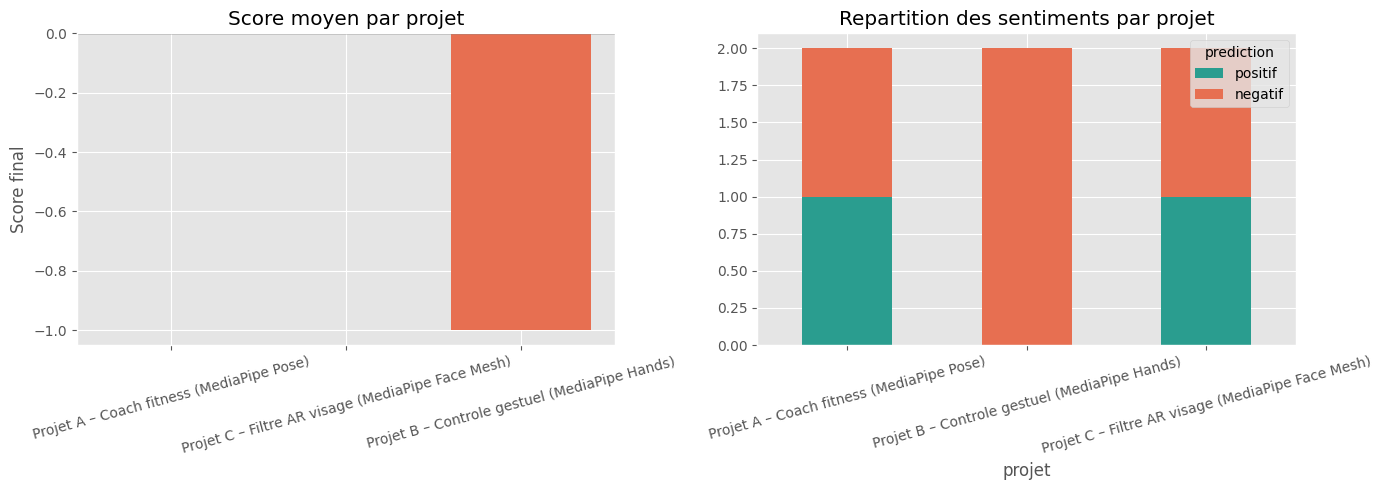

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2a9d8f", "#f4a261", "#e76f51"][:len(project_summary)]
axes[0].bar(project_summary["projet"], project_summary["score_final"], color=colors)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Score moyen par projet")
axes[0].set_ylabel("Score final")
axes[0].tick_params(axis="x", rotation=15)

counts = (
    comments_scored_df
    .pivot_table(index="projet", columns="prediction",
                 values="commentaire", aggfunc="count", fill_value=0)
    .reindex(columns=["positif", "negatif"], fill_value=0)
)
counts.plot(kind="bar", stacked=True, ax=axes[1],
            color=["#2a9d8f", "#e76f51"])
axes[1].set_title("Repartition des sentiments par projet")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout(); plt.show()

## 15. Application Flask

Mini-dashboard accessible depuis Colab via **ngrok**.  
Ajoutez `NGROK_AUTHTOKEN` dans les secrets Colab (https://dashboard.ngrok.com).

### what to do
- Lancer l app Flask et tester l ajout/import de commentaires.


In [ ]:
import importlib, subprocess, sys

def ensure_pkg(pkg):
    try:
        importlib.import_module(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure_pkg("flask")
ensure_pkg("pyngrok")


In [ ]:
import base64, io, threading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from flask import Flask, redirect, render_template_string, request, url_for
from werkzeug.serving import make_server

APP_STATE = {
    "comments": pd.DataFrame(columns=["auteur", "projet", "commentaire", "source"]),
}


def _normalize_csv(file_storage):
    df = pd.read_csv(file_storage, encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    df.rename(columns={
        "Donnez votre avis sur ce projet":       "commentaire",
        "Quel projet souhaitez-vous commenter ?": "projet",
        "Globalement, votre avis est :":          "sentiment_humain",
        "Nom ou pseudo":                          "auteur",
    }, inplace=True)
    if "auteur" not in df.columns:      df["auteur"] = "Import CSV"
    if "commentaire" not in df.columns: df["commentaire"] = ""
    if "projet" not in df.columns:      df["projet"] = ""
    df["source"] = "csv"
    df["commentaire"] = df["commentaire"].fillna("").astype(str).str.strip()
    df["projet"]      = df["projet"].fillna("").astype(str).str.strip()
    df = df[(df["commentaire"] != "") & (df["projet"] != "")].reset_index(drop=True)
    return df[["auteur", "projet", "commentaire", "source"]]


def _score_df(comment_frame):
    if comment_frame.empty:
        return pd.DataFrame()
    pred = predict_sentiment(final_model, comment_frame["commentaire"])
    scored = comment_frame.reset_index(drop=True).join(
        pred[["proba_negatif", "proba_positif", "confiance", "prediction"]]
    )
    scored["score"] = scored["prediction"].map(SCORE_MAP)
    return scored


def _summary_df(scored):
    if scored.empty:
        return pd.DataFrame()
    s = (scored.groupby("projet")
         .agg(
             nb=("commentaire", "size"),
             pos=("prediction", lambda x: (x == "positif").sum()),
             neg=("prediction", lambda x: (x == "negatif").sum()),
             score=("score", "mean"),
             taux=("prediction", lambda x: 100 * (x == "positif").mean()),
         )
         .reset_index()
         .sort_values("score", ascending=False)
         .reset_index(drop=True))
    s["rang"] = range(1, len(s) + 1)
    return s


def _fig_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=130)
    plt.close(fig)
    return base64.b64encode(buf.getvalue()).decode()


TEMPLATE = (
    "<!doctype html><html lang='fr'>"
    "<head><title>NLP Dashboard</title>"
    "<style>"
    "body{font-family:sans-serif;background:#f4f4f9;padding:20px}"
    ".card{background:white;border-radius:8px;padding:20px;margin-bottom:20px;"
    "box-shadow:0 2px 5px rgba(0,0,0,0.1)}"
    "table{width:100%;border-collapse:collapse;margin-top:10px}"
    "th,td{border-bottom:1px solid #ddd;padding:8px;text-align:left}"
    "button{background:#c2410c;color:white;border:none;padding:10px 15px;"
    "cursor:pointer;border-radius:4px}"
    "</style></head><body>"
    "<div class='card'>"
    "<h1>&#127916; Analyse de sentiment — Allocine 2 classes</h1>"
    "<form action='/upload_csv' method='post' enctype='multipart/form-data'>"
    "<input type='file' name='csv_file' accept='.csv'>"
    "<button type='submit'>Charger un CSV</button>"
    "<a href='/reset' style='margin-left:20px;color:#666'>Vider tout</a>"
    "</form></div>"
    "{% if not empty %}"
    "<div style='display:flex;gap:20px'>"
    "<div class='card' style='flex:1'><h2>Classement</h2>{{ summ|safe }}</div>"
    "<div class='card' style='flex:1'><img src='data:image/png;base64,{{ chart }}'></div>"
    "</div>"
    "<div class='card'><h2>Détail</h2>"
    "<div style='overflow-x:auto'>{{ detail|safe }}</div></div>"
    "{% else %}"
    "<div class='card'><p>Importez un fichier CSV pour lancer l'analyse.</p></div>"
    "{% endif %}"
    "</body></html>"
)

flask_app = Flask("nlp_dashboard")
flask_app.secret_key = "nlp_lab_secret"


@flask_app.route("/")
def index():
    scored  = _score_df(APP_STATE["comments"])
    summary = _summary_df(scored)
    chart   = ""
    if not summary.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(summary["projet"], summary["score"],
               color=["#2a9d8f", "#f4a261", "#e76f51"][:len(summary)])
        ax.axhline(0, color="black", lw=1)
        ax.set_title("Score moyen")
        ax.tick_params(axis="x", rotation=15)
        fig.tight_layout()
        chart = _fig_b64(fig)
    return render_template_string(
        TEMPLATE,
        summ=summary.to_html(classes="table", index=False) if not summary.empty else "",
        detail=scored.to_html(classes="table", index=False) if not scored.empty else "",
        chart=chart,
        empty=summary.empty,
    )


@flask_app.route("/upload_csv", methods=["POST"])
def upload_csv():
    f = request.files.get("csv_file")
    if f:
        imported = _normalize_csv(f)
        APP_STATE["comments"] = pd.concat([APP_STATE["comments"], imported], ignore_index=True)
    return redirect(url_for("index"))


@flask_app.route("/reset")
def reset():
    APP_STATE["comments"] = pd.DataFrame(columns=["auteur", "projet", "commentaire", "source"])
    return redirect(url_for("index"))

print("App Flask definie.")


App Flask definie.


In [ ]:
import os, threading
from pyngrok import ngrok
from werkzeug.serving import make_server

APP_PORT = 7860


class _ServerThread(threading.Thread):
    def __init__(self, app, port):
        super().__init__(daemon=True)
        self.server = make_server("0.0.0.0", port, app)

    def run(self):
        self.server.serve_forever()

    def shutdown(self):
        self.server.shutdown()


for _var in ("_flask_server", "_flask_tunnel"):
    if _var in globals() and globals()[_var] is not None:
        try:
            globals()[_var].shutdown()
        except Exception:
            pass
try:
    ngrok.kill()
except Exception:
    pass

_flask_server = _ServerThread(flask_app, APP_PORT)
_flask_server.start()

try:
    import google.colab  # noqa
    _running_colab = True
except Exception:
    _running_colab = False

_flask_tunnel = None
if _running_colab:
    token = os.environ.get("NGROK_AUTHTOKEN", "").strip()
    if not token:
        try:
            from google.colab import userdata
            token = (userdata.get("NGROK_AUTHTOKEN") or "").strip()
        except Exception:
            pass
    if token:
        ngrok.set_auth_token(token)
        _flask_tunnel = ngrok.connect(APP_PORT, bind_tls=True)
        print("App accessible :", _flask_tunnel.public_url)
    else:
        print("Ajoutez NGROK_AUTHTOKEN dans les secrets Colab et relancez.")
else:
    print(f"App locale : http://127.0.0.1:{APP_PORT}")


Ajoutez NGROK_AUTHTOKEN dans les secrets Colab et relancez.


## 16. Arrêter l'application Flask
### what to do
- Arreter proprement le serveur Flask.


In [ ]:
try:
    from pyngrok import ngrok as _ngrok
    if "_flask_tunnel" in globals() and _flask_tunnel:
        _ngrok.disconnect(_flask_tunnel.public_url)
    _ngrok.kill()
except Exception:
    pass

if "_flask_server" in globals() and _flask_server:
    _flask_server.shutdown()
    print("Serveur Flask arrete.")
else:
    print("Aucun serveur actif.")


Serveur Flask arrete.


## 17. Conclusion

Pipeline NLP complet en français (baseline 2 classes) :
- dataset **Allocine** (positif / negatif) ;
- nettoyage + lemmatisation spaCy ;
- **BoW** et **TF-IDF** ;
- **5 algorithmes** comparés avec F1 pondéré ;
- inférence avec score de confiance ;
- app **Flask** avec import CSV et ngrok.

### Pourquoi les Transformers (CamemBERT, DistilCamemBERT, etc.) ?
- Les approches classiques (BoW/TF-IDF) voient surtout des **comptages de mots** : peu de contexte, gestion limitée des négations/sarcasmes, vocabulaire figé.
- Les Transformers utilisent l'**attention** et des embeddings **contextuels** (sens selon la phrase) + tokenisation en sous-mots → souvent meilleurs en sentiment et plus robustes au domain shift.
- Limites : plus lents, plus lourds à déployer (GPU souvent utile), fine-tuning plus coûteux.

### Pistes d'amélioration
- `ngram_range=(1,3)` vs `(1,2)` ;
- remplacer TF-IDF par CamemBERT via `transformers` ;
- interface Streamlit ;
- Google Forms → collecte des vrais commentaires.


### À lire
- *Attention Is All You Need* (Vaswani et al., NeurIPS 2017) : https://proceedings.neurips.cc/paper_files/paper/2017/hash/3f5ee243547dee91fbd053c1c4a845aa-Abstract.html

### what to do
- Ecrire une conclusion (limites, pistes d amelioration).
